# Residual-stream separability analysis (no affective-axis dependency)

This notebook tests whether `positive_rewrite` and `negative_rewrite` residual-stream activations are linearly separable across layers, without using `affective_axis` labels.

Main goals:
- Check visual separability via PCA (diagnostic only).
- Quantify separability via logistic regression with group-aware splits when `source_ids` exist.
- Test whether a common positive-minus-negative direction exists and is stable across layers.
- Report potential confounds from source/base identity effects.

In [1]:
from pathlib import Path
import os

# limit the BLAS threads count (because wsl dies)
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import gc
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from IPython.display import display
from tqdm.auto import tqdm

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
MAX_PCA_POINTS = 3000
MAX_PAIR_PLOT_PAIRS = 300
MAX_PAIRWISE_D_SAMPLES = 2000
MAX_CLASSIFY_SAMPLES = 5000
PAIRWISE_BLOCK_SIZE = 512
PAIRWISE_HIST_SAMPLE_SIZE = 800
N_SPLITS = 5
TEST_SIZE = 0.2
N_WORKERS = 1
CLASSIFY_IN_PARALLEL = False

ROOT = Path(".").resolve()
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def resolve_data_path(root: Path) -> Path:
    candidates = [
        root / "data/activations/residual_stream.pt",
        root / "../data/activations/residual_stream.pt",
        root / "dataset/activations/residual_stream.pt",
        root / "../dataset/activations/residual_stream.pt",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find residual_stream.pt. Checked: "
        + ", ".join(str(p) for p in candidates)
    )


def l2_normalize(x: np.ndarray, axis: int = -1, eps: float = 1e-12) -> np.ndarray:
    norm = np.linalg.norm(x, axis=axis, keepdims=True)
    return x / np.maximum(norm, eps)


def summarize_pairwise_cosine_blockwise(V: np.ndarray, block_size: int = 512) -> dict[str, float]:
    n = V.shape[0]
    if n < 2:
        return {
            "n_offdiag_pairs": 0,
            "mean_offdiag_cosine": np.nan,
            "std_offdiag_cosine": np.nan,
            "median_offdiag_cosine": np.nan,
            "fraction_offdiag_positive": np.nan,
        }

    total_pairs = n * (n - 1) // 2
    sum_val = 0.0
    sum_sq = 0.0
    pos_count = 0

    # ブロック単位で off-diagonal の統計量を集約して、巨大な n x n 行列の構築を避ける。
    for i0 in range(0, n, block_size):
        i1 = min(i0 + block_size, n)
        Vi = V[i0:i1]

        for j0 in range(i0, n, block_size):
            j1 = min(j0 + block_size, n)
            Vj = V[j0:j1]

            sim_block = Vi @ Vj.T

            if i0 == j0:
                iu = np.triu_indices(i1 - i0, k=1)
                vals = sim_block[iu]
            else:
                vals = sim_block.ravel()

            if vals.size == 0:
                continue

            sum_val += float(np.sum(vals))
            sum_sq += float(np.sum(vals * vals))
            pos_count += int(np.sum(vals > 0.0))

    mean_val = sum_val / total_pairs
    var_val = max(sum_sq / total_pairs - mean_val * mean_val, 0.0)
    std_val = float(np.sqrt(var_val))

    # median のみ推定ではなく厳密値を得るために、小さめサンプルで補助計算する。
    sample_n = min(PAIRWISE_HIST_SAMPLE_SIZE, n)
    sample_idx = np.random.default_rng(RANDOM_STATE).choice(n, size=sample_n, replace=False)
    V_sample = V[sample_idx]
    sim_sample = V_sample @ V_sample.T
    sample_offdiag = sim_sample[np.triu_indices(sample_n, k=1)]
    median_val = float(np.median(sample_offdiag)) if sample_offdiag.size > 0 else np.nan

    return {
        "n_offdiag_pairs": int(total_pairs),
        "mean_offdiag_cosine": float(mean_val),
        "std_offdiag_cosine": std_val,
        "median_offdiag_cosine": median_val,
        "fraction_offdiag_positive": float(pos_count / total_pairs),
    }


DATA_PATH = resolve_data_path(ROOT)
payload = torch.load(DATA_PATH, map_location="cpu")
activations = payload["activations"].cpu().numpy()
d_pos_neg_tensor = payload.get("d_pos_neg", None)
d_pos_neg = d_pos_neg_tensor.cpu().numpy() if isinstance(d_pos_neg_tensor, torch.Tensor) else None

layer_indices = list(payload.get("layer_indices", []))
source_ids_raw = payload.get("source_ids", None)
source_ids = np.asarray(source_ids_raw) if source_ids_raw is not None else None
text_order = payload.get("text_order", None)

if activations.ndim != 4:
    raise ValueError(f"Expected activations with shape (N, 3, L, D), got {activations.shape}")

N, n_text_variants, n_layers, hidden_dim = activations.shape
if len(layer_indices) != n_layers:
    warnings.warn(
        "layer_indices missing or length mismatch. Falling back to 0..L-1 tensor positions.",
        RuntimeWarning,
    )
    layer_indices = list(range(n_layers))

has_valid_source_ids = source_ids is not None and len(source_ids) == N
if source_ids is not None and len(source_ids) != N:
    warnings.warn(
        f"source_ids length ({len(source_ids)}) does not match N ({N}). Falling back to non-grouped split.",
        RuntimeWarning,
    )
    source_ids = None
    has_valid_source_ids = False

print(f"Loaded payload from: {DATA_PATH}")
print(f"Activations shape: {activations.shape}  dtype: {activations.dtype}")


/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded payload from: /home/maplesugano/proj/EmotionEngine_v2/dataset/activations/residual_stream.pt
Activations shape: (22580, 3, 6, 4096)  dtype: float32


## 1) Basic metadata checks

We verify core tensor structure and metadata before running any analysis.

Interpretation note:
- Shape checks help ensure we are comparing the intended positive (`h_pos`) and negative (`h_neg`) streams at each layer.
- `text_order` and `source_ids` are optional and used only when available.

In [2]:
print("activations shape:", activations.shape)
print("d_pos_neg shape:", None if d_pos_neg is None else d_pos_neg.shape)
print("N:", N)
print("number of stored text variants:", n_text_variants)
print("number of layers:", n_layers)
print("hidden dimension:", hidden_dim)
print("layer_indices:", layer_indices)

if text_order is not None:
    print("text_order:", list(text_order))
else:
    print("text_order: not available")

if source_ids is not None:
    print("number of unique source_ids:", len(np.unique(source_ids)))
else:
    print("number of unique source_ids: not available")

activations shape: (22580, 3, 6, 4096)
d_pos_neg shape: (22580, 6, 4096)
N: 22580
number of stored text variants: 3
number of layers: 6
hidden dimension: 4096
layer_indices: [8, 10, 13, 16, 19, 22]
text_order: ['base_text', 'positive_rewrite', 'negative_rewrite']
number of unique source_ids: 22580


## 2) Layer-wise PCA diagnostics and linear classification

For each layer, we build:
- `X = [h_pos; h_neg]`, `y = [1, ..., 1, 0, ..., 0]`
- PCA scatter (2D) colored only by positive vs negative
- A paired PCA plot connecting each (`h_neg`, `h_pos`) example pair for a random subset
- Logistic regression metrics (accuracy, balanced accuracy, ROC-AUC)

Interpretation notes:
- If positive and negative points separate, this suggests a candidate linear representation.
- PCA is only a visual diagnostic and is not sufficient evidence by itself.
- If grouped classification (by `source_id`) remains strong, source identity alone is less likely to explain the separation.

Layer classification + PCA:   0%|          | 0/6 [00:00<?, ?it/s]

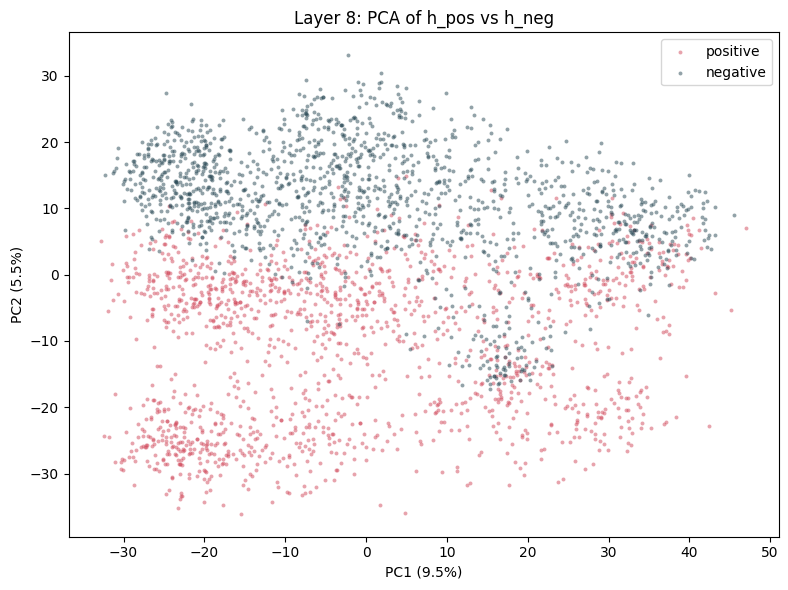

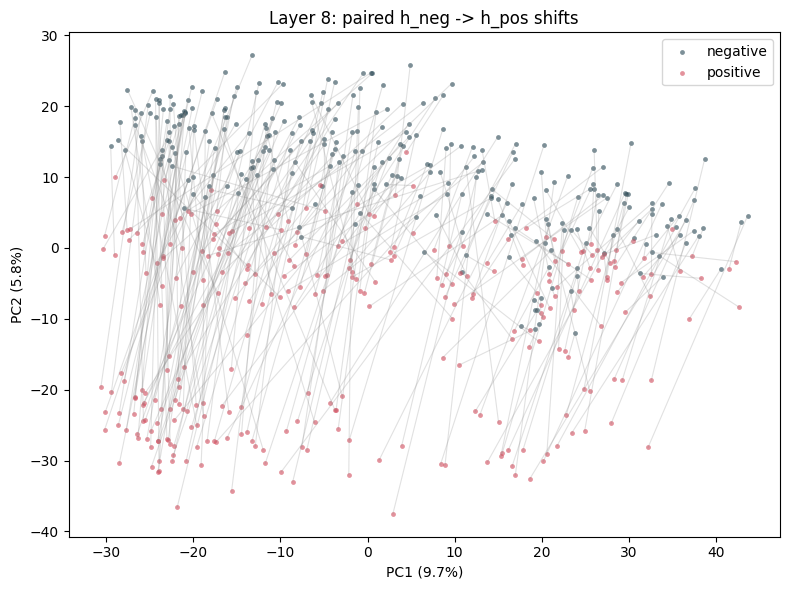

Layer classification + PCA:  17%|█▋        | 1/6 [00:20<01:43, 20.68s/it]

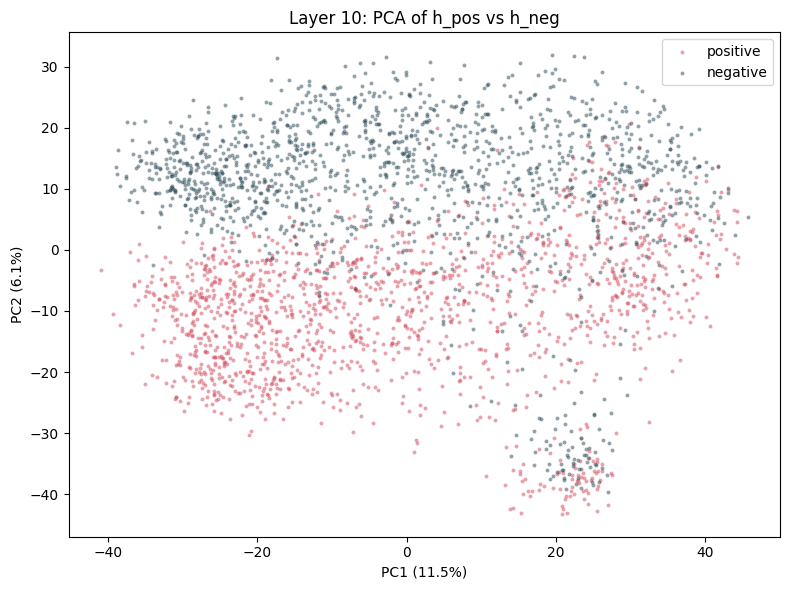

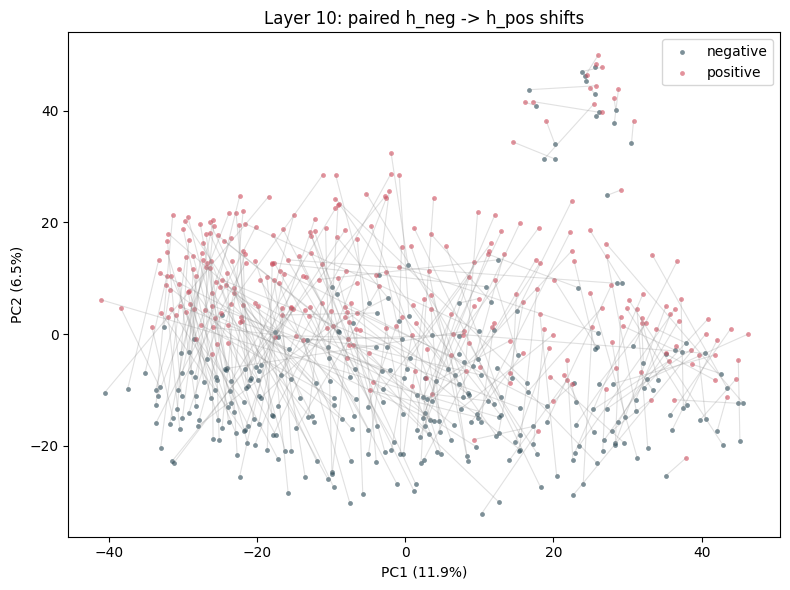

Layer classification + PCA:  33%|███▎      | 2/6 [00:38<01:16, 19.08s/it]

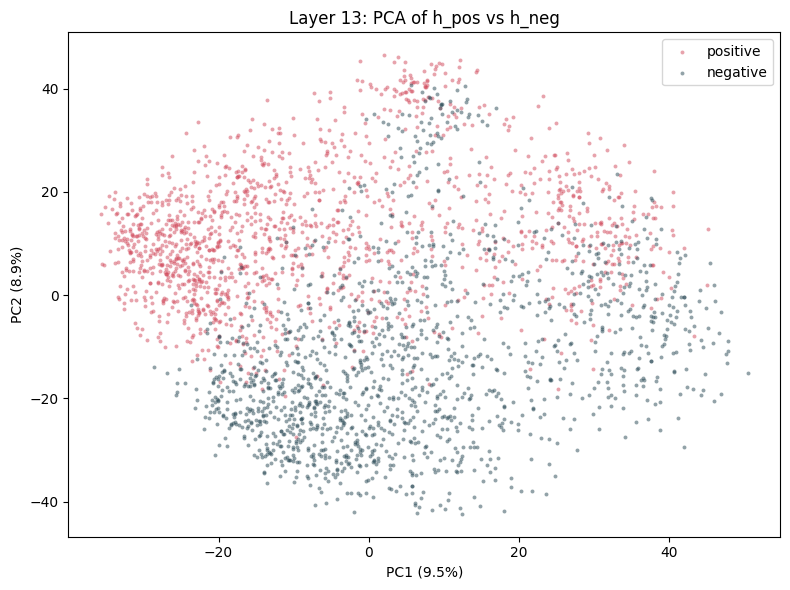

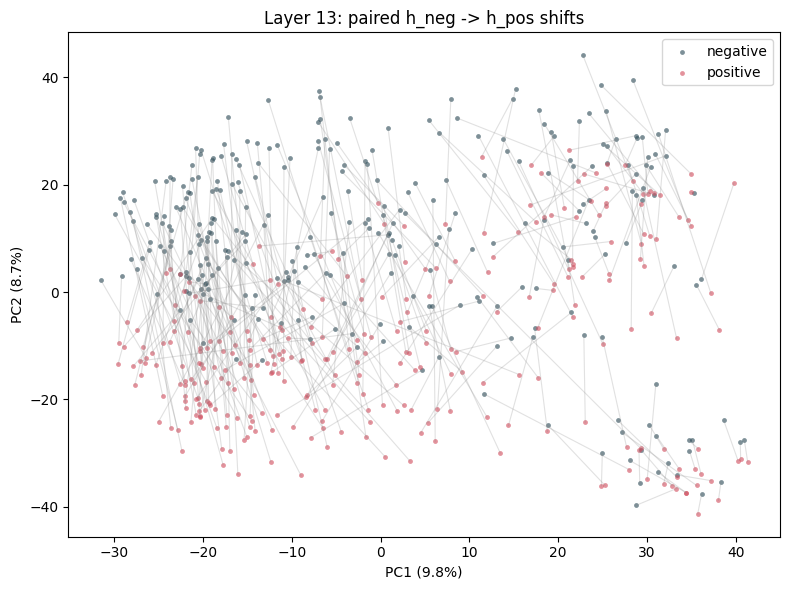

Layer classification + PCA:  50%|█████     | 3/6 [00:53<00:50, 16.94s/it]

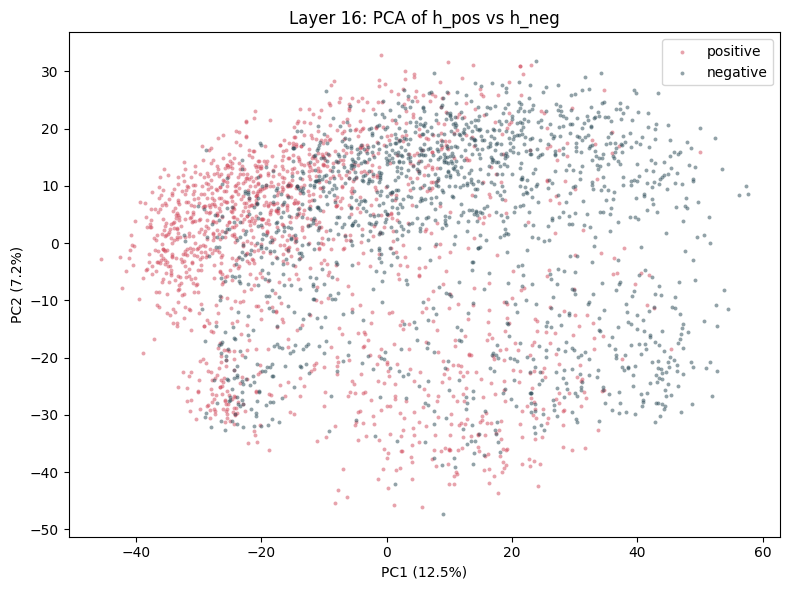

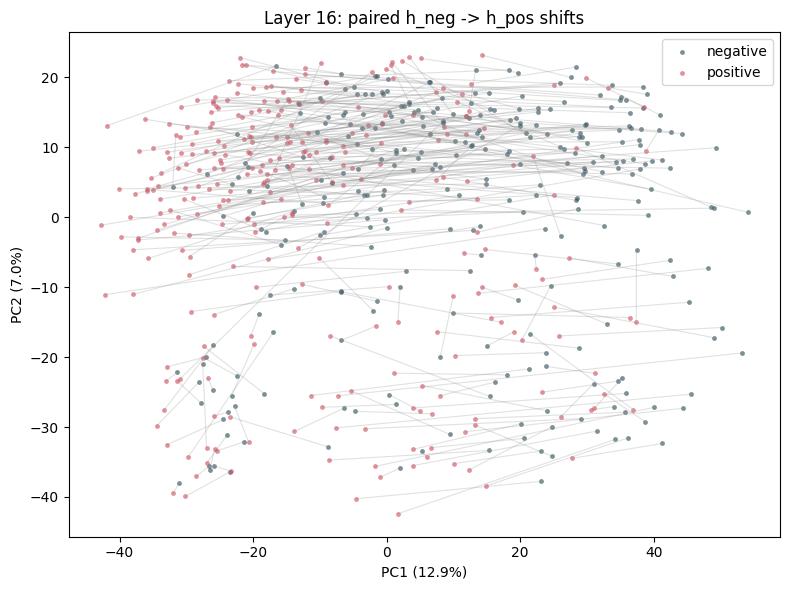

Layer classification + PCA:  67%|██████▋   | 4/6 [01:07<00:32, 16.11s/it]

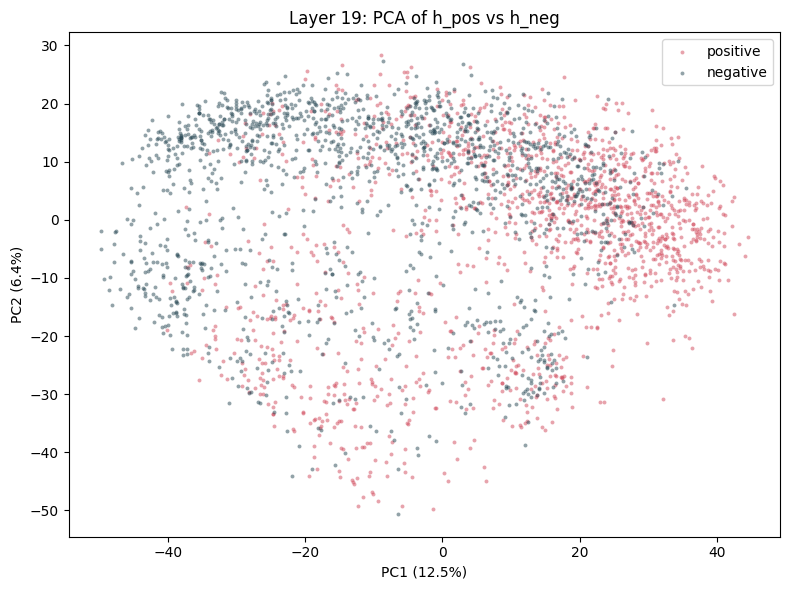

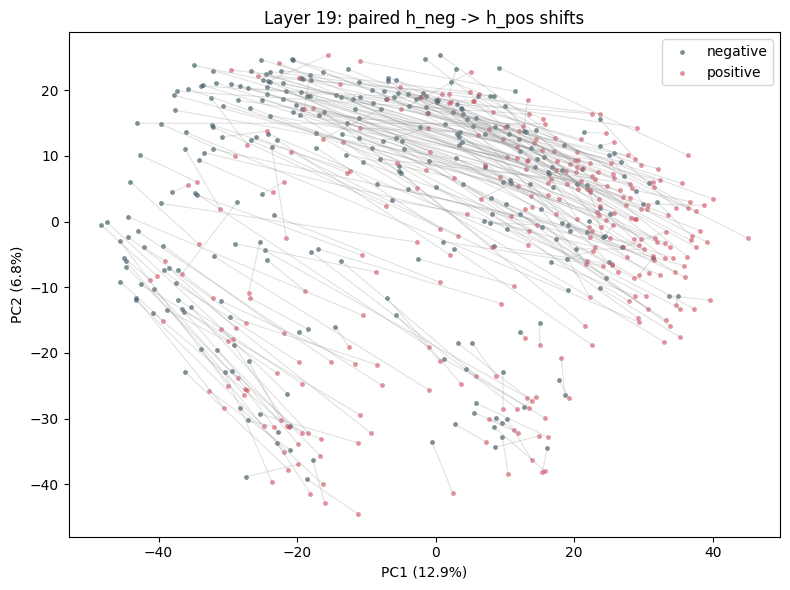

Layer classification + PCA:  83%|████████▎ | 5/6 [01:27<00:17, 17.22s/it]

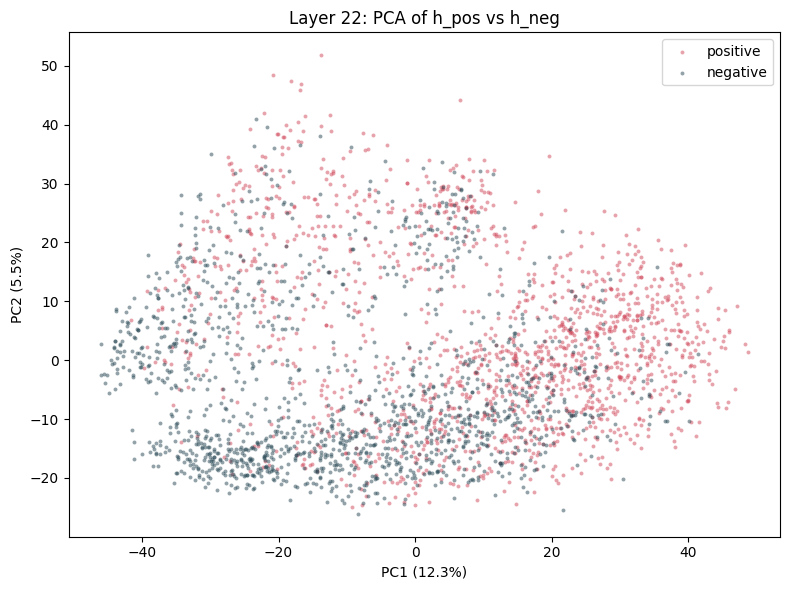

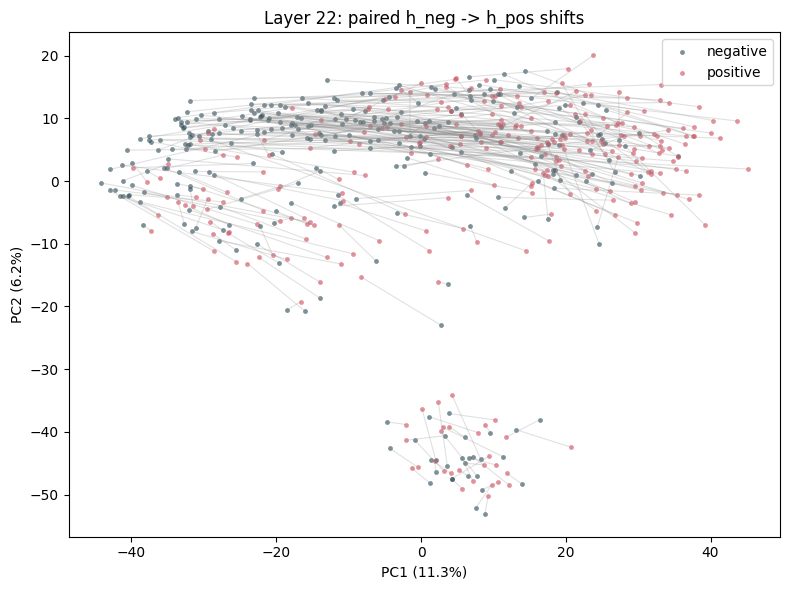

Layer classification + PCA: 100%|██████████| 6/6 [01:46<00:00, 17.79s/it]


,layer,n_rows,n_samples,split_strategy,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std
0,8,22580,5000,GroupShuffleSplit(source_id),0.988759,0.003431,0.988858,0.003383,0.999242,0.000209
1,10,22580,5000,GroupShuffleSplit(source_id),0.993603,0.002585,0.993534,0.002613,0.999792,0.000147
2,13,22580,5000,GroupShuffleSplit(source_id),0.997008,0.001395,0.996948,0.001421,0.999943,0.000024
3,16,22580,5000,GroupShuffleSplit(source_id),0.995178,0.001346,0.995187,0.001363,0.999910,0.000069
4,19,22580,5000,GroupShuffleSplit(source_id),0.990207,0.001880,0.990152,0.001870,0.999618,0.000139


Saved layer metrics to: /home/maplesugano/proj/EmotionEngine_v2/caa/results/separability_layer_metrics.csv


In [3]:
rng = np.random.default_rng(RANDOM_STATE)


def run_layer_classification(X: np.ndarray, y: np.ndarray, groups: np.ndarray | None):
    split_rows = []

    if groups is not None:
        splitter = GroupShuffleSplit(
            n_splits=N_SPLITS,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
        )
        split_iter = splitter.split(X, y, groups)
        split_strategy = "GroupShuffleSplit(source_id)"
    else:
        splitter = StratifiedShuffleSplit(
            n_splits=N_SPLITS,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
        )
        split_iter = splitter.split(X, y)
        split_strategy = "StratifiedShuffleSplit(no_groups)"

    for split_id, (train_idx, test_idx) in enumerate(split_iter):
        model = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                (
                    "clf",
                    LogisticRegression(
                        max_iter=2000,
                        solver="liblinear",
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )
        model.fit(X[train_idx], y[train_idx])

        prob = model.predict_proba(X[test_idx])[:, 1]
        pred = (prob >= 0.5).astype(int)

        try:
            roc_auc = roc_auc_score(y[test_idx], prob)
        except ValueError:
            roc_auc = np.nan

        split_rows.append(
            {
                "split": split_id,
                "accuracy": accuracy_score(y[test_idx], pred),
                "balanced_accuracy": balanced_accuracy_score(y[test_idx], pred),
                "roc_auc": roc_auc,
                "n_train": int(len(train_idx)),
                "n_test": int(len(test_idx)),
                "split_strategy": split_strategy,
            }
        )

    return pd.DataFrame(split_rows)


split_metrics_frames = []
layer_metric_rows = []

for layer_pos, layer_number in tqdm(
    list(enumerate(layer_indices)),
    desc="Layer classification + PCA",
):
    h_pos = activations[:, 1, layer_pos, :]
    h_neg = activations[:, 2, layer_pos, :]
    X = np.concatenate([h_pos, h_neg], axis=0)
    y = np.concatenate(
        [
            np.ones(h_pos.shape[0], dtype=np.int64),
            np.zeros(h_neg.shape[0], dtype=np.int64),
        ]
    )
    groups = np.repeat(source_ids, 2) if has_valid_source_ids else None

    if X.shape[0] > MAX_CLASSIFY_SAMPLES:
        clf_rng = np.random.default_rng(RANDOM_STATE + layer_pos)
        clf_idx = clf_rng.choice(X.shape[0], size=MAX_CLASSIFY_SAMPLES, replace=False)
        X_clf = X[clf_idx]
        y_clf = y[clf_idx]
        groups_clf = groups[clf_idx] if groups is not None else None
    else:
        X_clf, y_clf, groups_clf = X, y, groups

    split_df = run_layer_classification(X=X_clf, y=y_clf, groups=groups_clf)
    split_df["layer"] = layer_number

    layer_row = {
        "layer": layer_number,
        "n_rows": int(N),
        "n_samples": int(X_clf.shape[0]),
        "split_strategy": split_df["split_strategy"].iloc[0],
        "accuracy_mean": split_df["accuracy"].mean(),
        "accuracy_std": split_df["accuracy"].std(ddof=0),
        "balanced_accuracy_mean": split_df["balanced_accuracy"].mean(),
        "balanced_accuracy_std": split_df["balanced_accuracy"].std(ddof=0),
        "roc_auc_mean": split_df["roc_auc"].mean(),
        "roc_auc_std": split_df["roc_auc"].std(ddof=0),
    }
    split_metrics_frames.append(split_df)
    layer_metric_rows.append(layer_row)
    del X_clf, y_clf, groups_clf, split_df

    # PCA diagnostic scatter (subsample for plotting only)
    plot_size = min(MAX_PCA_POINTS, X.shape[0])
    plot_idx = rng.choice(X.shape[0], size=plot_size, replace=False)
    X_plot = X[plot_idx]
    y_plot = y[plot_idx]

    X_plot_scaled = StandardScaler().fit_transform(X_plot)
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    Z = pca.fit_transform(X_plot_scaled)
    del X_plot_scaled

    fig, ax = plt.subplots(figsize=(8, 6))
    mask_pos = y_plot == 1
    mask_neg = y_plot == 0
    ax.scatter(
        Z[mask_pos, 0], Z[mask_pos, 1],
        s=8, alpha=0.5, c="#d1495b", label="positive", linewidths=0,
    )
    ax.scatter(
        Z[mask_neg, 0], Z[mask_neg, 1],
        s=8, alpha=0.5, c="#264653", label="negative", linewidths=0,
    )
    ax.set_title(f"Layer {layer_number}: PCA of h_pos vs h_neg")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
    ax.legend(frameon=True)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"pca_pos_neg_layer_{layer_number}.png", dpi=200)
    display(fig)
    plt.close(fig)
    del X_plot, y_plot, Z, pca, fig, ax

    # Paired PCA plot to inspect per-example shift direction
    pair_count = min(MAX_PAIR_PLOT_PAIRS, N)
    pair_idx = rng.choice(N, size=pair_count, replace=False)
    pair_pos = h_pos[pair_idx]
    pair_neg = h_neg[pair_idx]

    pair_stack = np.concatenate([pair_neg, pair_pos], axis=0)
    pair_stack_scaled = StandardScaler().fit_transform(pair_stack)
    pair_pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pair_Z = pair_pca.fit_transform(pair_stack_scaled)
    z_neg_p = pair_Z[:pair_count]
    z_pos_p = pair_Z[pair_count:]
    del pair_stack_scaled

    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(pair_count):
        ax.plot(
            [z_neg_p[i, 0], z_pos_p[i, 0]],
            [z_neg_p[i, 1], z_pos_p[i, 1]],
            color="#888888",
            alpha=0.25,
            linewidth=0.8,
        )
    ax.scatter(z_neg_p[:, 0], z_neg_p[:, 1], s=12, alpha=0.6, c="#264653", label="negative", linewidths=0)
    ax.scatter(z_pos_p[:, 0], z_pos_p[:, 1], s=12, alpha=0.6, c="#d1495b", label="positive", linewidths=0)
    ax.set_title(f"Layer {layer_number}: paired h_neg -> h_pos shifts")
    ax.set_xlabel(f"PC1 ({pair_pca.explained_variance_ratio_[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pair_pca.explained_variance_ratio_[1] * 100:.1f}%)")
    ax.legend(frameon=True)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"pca_pairs_layer_{layer_number}.png", dpi=200)
    display(fig)
    plt.close(fig)
    del pair_pos, pair_neg, pair_stack, pair_Z, z_neg_p, z_pos_p, pair_pca, fig, ax

    del X, y, groups
    gc.collect()


layer_metrics = pd.DataFrame(layer_metric_rows).sort_values("layer").reset_index(drop=True)
layer_split_metrics = pd.concat(split_metrics_frames, ignore_index=True)

layer_metrics.to_csv(RESULTS_DIR / "separability_layer_metrics.csv", index=False)
layer_split_metrics.to_csv(RESULTS_DIR / "separability_layer_split_metrics.csv", index=False)

if not has_valid_source_ids:
    warnings.warn(
        "source_ids unavailable. Used StratifiedShuffleSplit; performance may be overestimated due to source leakage.",
        RuntimeWarning,
    )

display(layer_metrics.head())
print(f"Saved layer metrics to: {RESULTS_DIR / 'separability_layer_metrics.csv'}")


## 3) Mean steering vector consistency and pairwise d-pos-neg consistency

For each layer:
- Compute `d_i = h_pos[i] - h_neg[i]`
- Compute normalized mean vector `v = mean(d_i)`
- Measure cosine consistency `cos(d_i, v)`

Also, using stored `d_pos_neg` when available:
- Sample up to 2000 vectors per layer
- Compute pairwise cosine similarities and summarize off-diagonal behavior

Interpretation notes:
- High positive `cos(d_i, v)` suggests a shared direction.
- High positive off-diagonal pairwise cosine suggests many examples align to a common direction.
- Near-zero pairwise cosine suggests noisy or multi-directional differences.

Vector consistency:   0%|          | 0/6 [00:00<?, ?it/s]

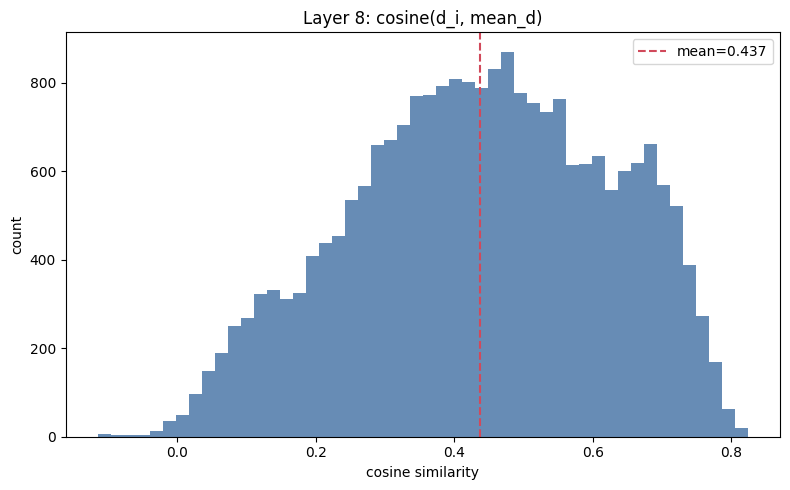

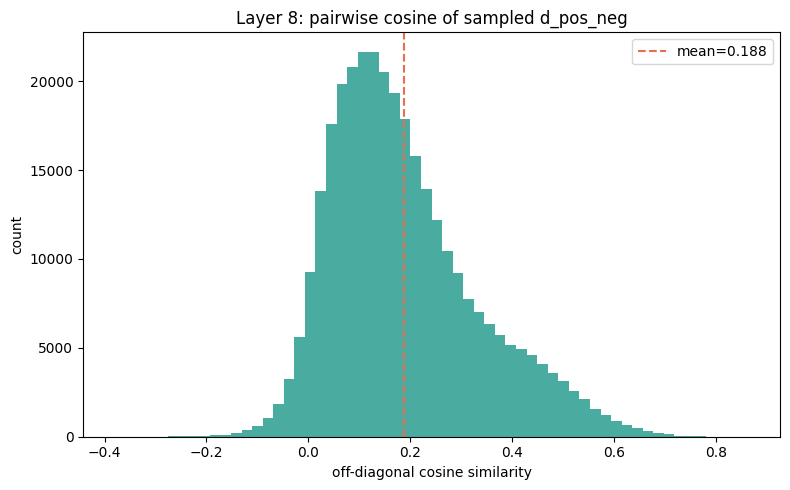

Vector consistency:  17%|█▋        | 1/6 [00:00<00:03,  1.34it/s]

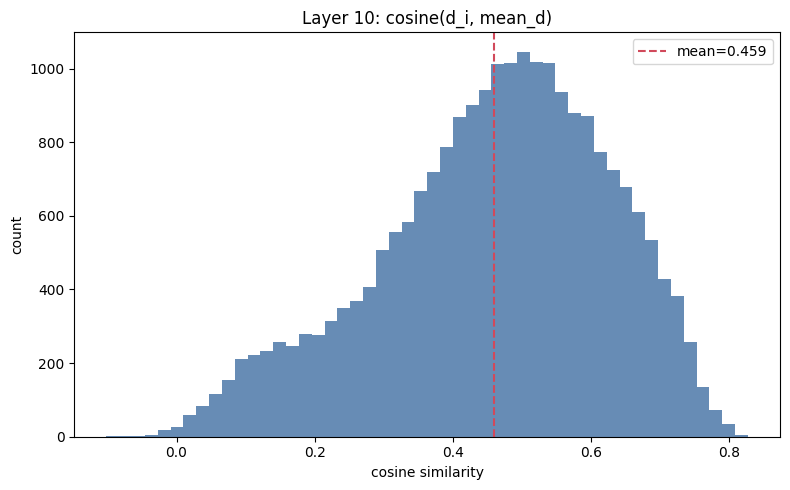

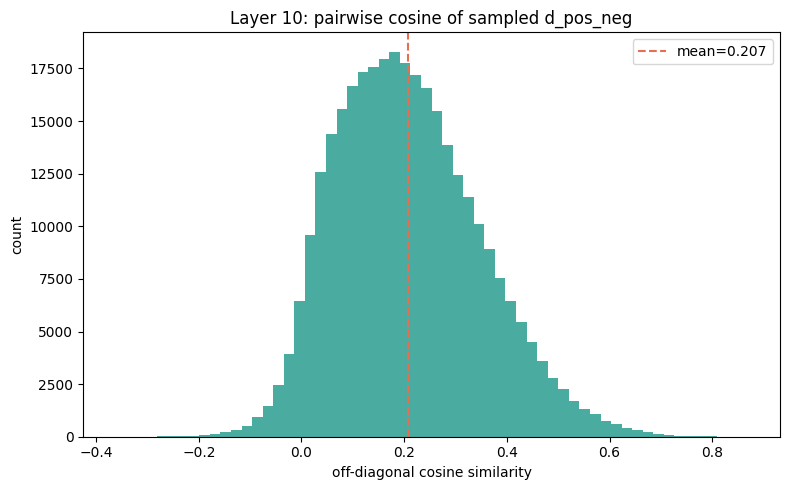

Vector consistency:  33%|███▎      | 2/6 [00:01<00:03,  1.30it/s]

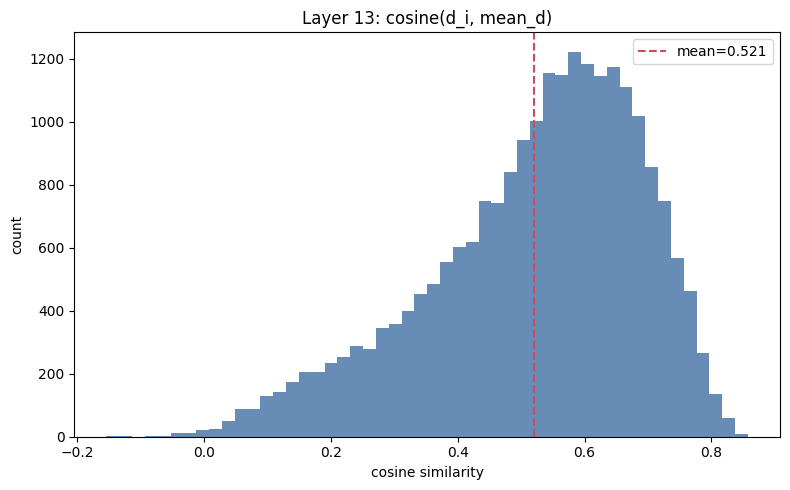

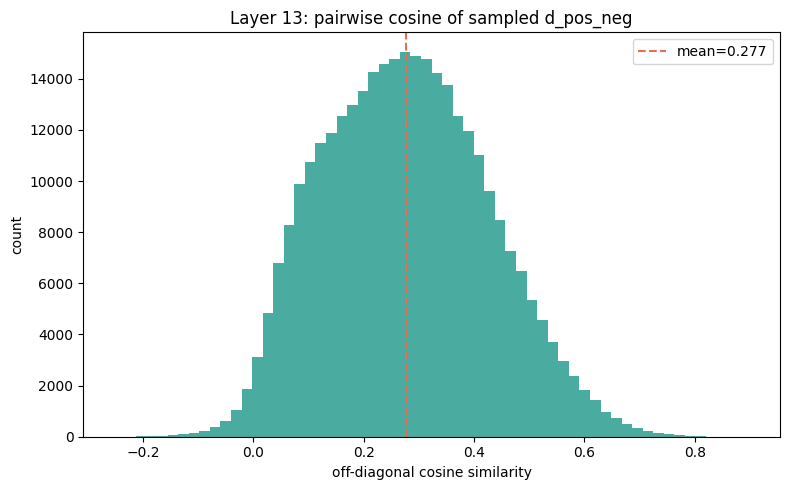

Vector consistency:  50%|█████     | 3/6 [00:02<00:02,  1.32it/s]

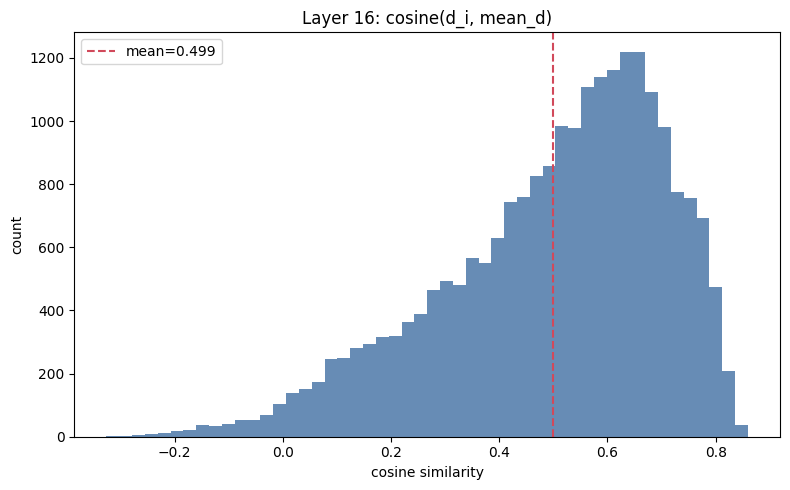

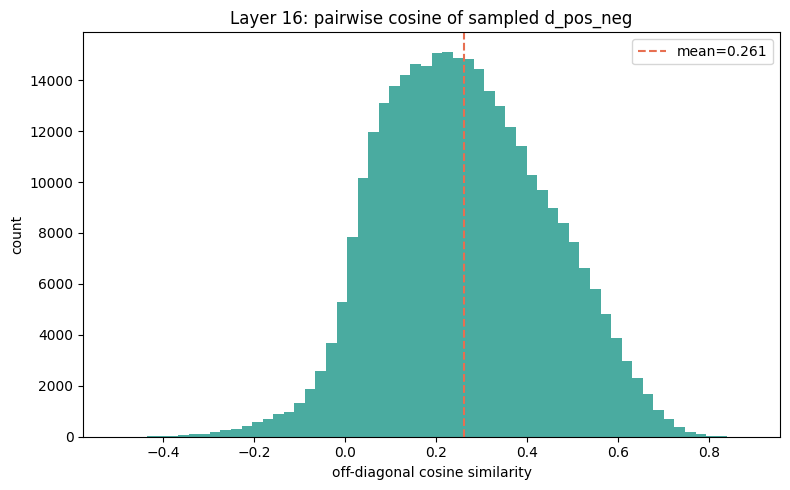

Vector consistency:  67%|██████▋   | 4/6 [00:03<00:01,  1.34it/s]

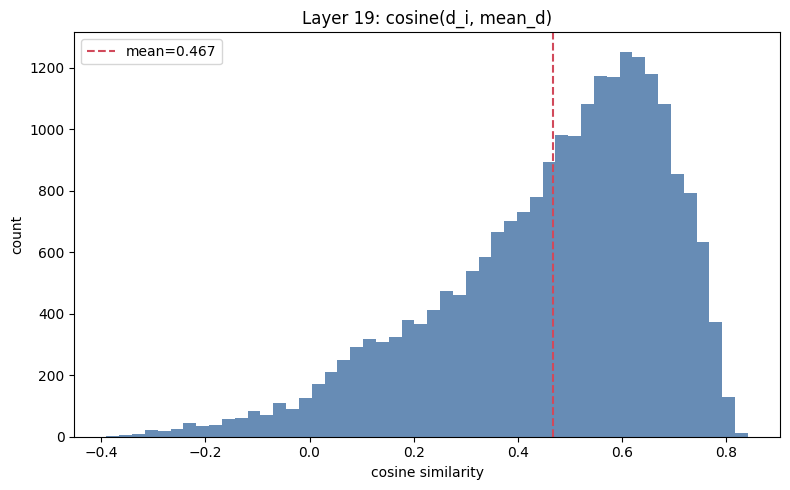

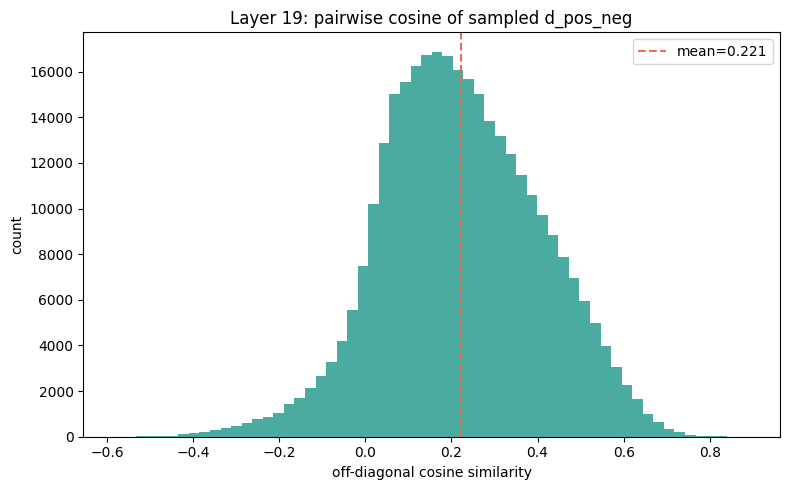

Vector consistency:  83%|████████▎ | 5/6 [00:03<00:00,  1.33it/s]

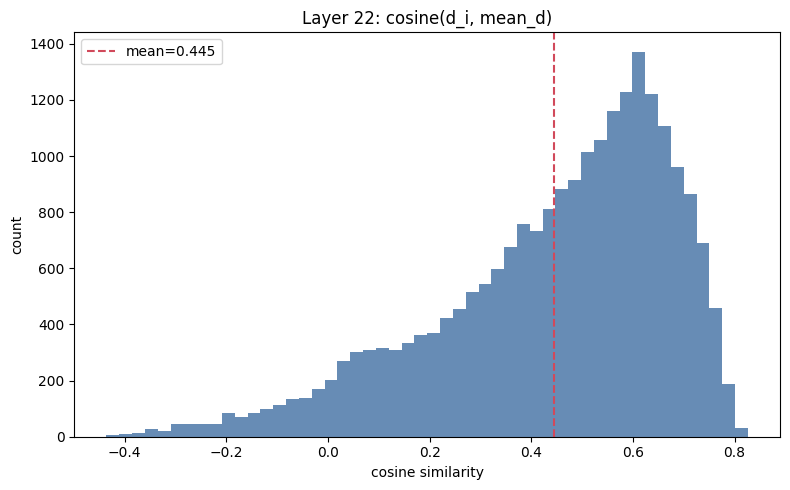

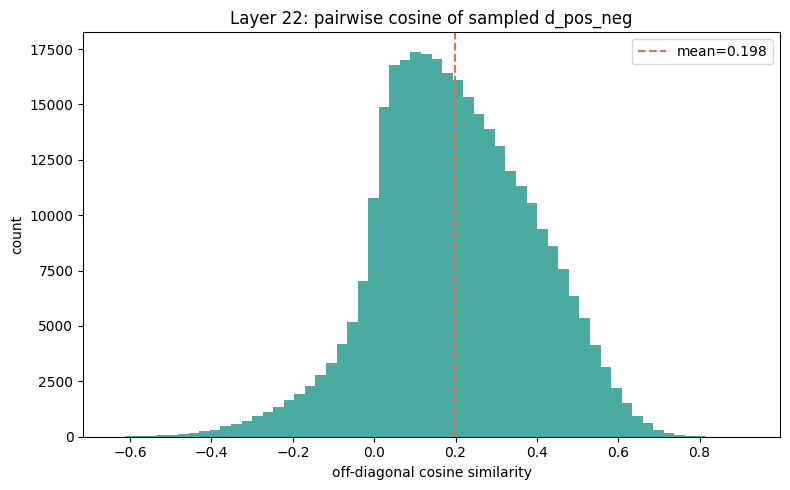

Vector consistency: 100%|██████████| 6/6 [00:04<00:00,  1.33it/s]


,layer,n_rows,cosine_mean,cosine_std,cosine_median,fraction_positive,fraction_above_0_1,fraction_above_0_2
0,8,22580,0.436763,0.184344,0.442540,0.996944,0.959566,0.881709
1,10,22580,0.459112,0.166623,0.476707,0.998406,0.971612,0.912755
2,13,22580,0.521090,0.168999,0.551303,0.998229,0.983260,0.944066
3,16,22580,0.499493,0.207774,0.540837,0.980868,0.948450,0.895438
4,19,22580,0.466826,0.217672,0.514437,0.965810,0.925421,0.866076


,layer,n_sampled_vectors,n_offdiag_pairs,mean_offdiag_cosine,std_offdiag_cosine,median_offdiag_cosine,fraction_offdiag_positive
0,8,2000,1999000,0.189838,0.143789,0.161413,0.951346
1,10,2000,1999000,0.209136,0.142100,0.197600,0.954748
2,13,2000,1999000,0.270917,0.152608,0.258738,0.980926
3,16,2000,1999000,0.246024,0.185717,0.237817,0.926822
4,19,2000,1999000,0.218100,0.180397,0.205835,0.906360


In [4]:
vector_rows = []
pairwise_rows = []
mean_vectors = {}

for layer_pos, layer_number in tqdm(
    list(enumerate(layer_indices)),
    desc="Vector consistency",
):
    h_pos = activations[:, 1, layer_pos, :]
    h_neg = activations[:, 2, layer_pos, :]

    d_layer = h_pos - h_neg
    v_layer = d_layer.mean(axis=0)
    v_layer = l2_normalize(v_layer.reshape(1, -1))[0]
    mean_vectors[layer_number] = v_layer

    d_norm = l2_normalize(d_layer)
    cosine_values = d_norm @ v_layer

    vector_rows.append(
        {
            "layer": layer_number,
            "n_rows": int(len(cosine_values)),
            "cosine_mean": float(np.mean(cosine_values)),
            "cosine_std": float(np.std(cosine_values, ddof=0)),
            "cosine_median": float(np.median(cosine_values)),
            "fraction_positive": float(np.mean(cosine_values > 0.0)),
            "fraction_above_0_1": float(np.mean(cosine_values > 0.1)),
            "fraction_above_0_2": float(np.mean(cosine_values > 0.2)),
        }
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(cosine_values, bins=50, color="#4c78a8", alpha=0.85)
    ax.axvline(np.mean(cosine_values), color="#d1495b", linestyle="--", linewidth=1.5, label=f"mean={np.mean(cosine_values):.3f}")
    ax.set_title(f"Layer {layer_number}: cosine(d_i, mean_d)")
    ax.set_xlabel("cosine similarity")
    ax.set_ylabel("count")
    ax.legend(frameon=True)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"cosine_hist_layer_{layer_number}.png", dpi=200)
    display(fig)
    plt.close(fig)

    try:
        if d_pos_neg is None:
            raise KeyError("d_pos_neg is not available in payload")

        d_raw = d_pos_neg[:, layer_pos, :]
        sample_n = min(MAX_PAIRWISE_D_SAMPLES, d_raw.shape[0])
        sample_idx = rng.choice(d_raw.shape[0], size=sample_n, replace=False)

        V = l2_normalize(d_raw[sample_idx])
        pairwise_stats = summarize_pairwise_cosine_blockwise(V, block_size=PAIRWISE_BLOCK_SIZE)

        pairwise_rows.append(
            {
                "layer": layer_number,
                "n_sampled_vectors": int(sample_n),
                "n_offdiag_pairs": pairwise_stats["n_offdiag_pairs"],
                "mean_offdiag_cosine": pairwise_stats["mean_offdiag_cosine"],
                "std_offdiag_cosine": pairwise_stats["std_offdiag_cosine"],
                "median_offdiag_cosine": pairwise_stats["median_offdiag_cosine"],
                "fraction_offdiag_positive": pairwise_stats["fraction_offdiag_positive"],
            }
        )

        # 図は高速化のため全ペアではなくサンプル集合から作成する。
        hist_n = min(PAIRWISE_HIST_SAMPLE_SIZE, sample_n)
        hist_idx = rng.choice(sample_n, size=hist_n, replace=False)
        V_hist = V[hist_idx]
        sim_hist = V_hist @ V_hist.T
        offdiag_hist = sim_hist[np.triu_indices(hist_n, k=1)]

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.hist(offdiag_hist, bins=60, color="#2a9d8f", alpha=0.85)
        if offdiag_hist.size > 0:
            ax.axvline(np.mean(offdiag_hist), color="#e76f51", linestyle="--", linewidth=1.5, label=f"mean={np.mean(offdiag_hist):.3f}")
        ax.set_title(f"Layer {layer_number}: pairwise cosine of sampled d_pos_neg")
        ax.set_xlabel("off-diagonal cosine similarity")
        ax.set_ylabel("count")
        ax.legend(frameon=True)
        fig.tight_layout()
        fig.savefig(FIGURES_DIR / f"pairwise_cosine_hist_layer_{layer_number}.png", dpi=200)
        display(fig)
        plt.close(fig)
    except Exception as exc:
        warnings.warn(f"Skipped pairwise d_pos_neg analysis at layer {layer_number}: {exc}", RuntimeWarning)
        pairwise_rows.append(
            {
                "layer": layer_number,
                "n_sampled_vectors": np.nan,
                "n_offdiag_pairs": np.nan,
                "mean_offdiag_cosine": np.nan,
                "std_offdiag_cosine": np.nan,
                "median_offdiag_cosine": np.nan,
                "fraction_offdiag_positive": np.nan,
            }
        )

vector_consistency = pd.DataFrame(vector_rows).sort_values("layer").reset_index(drop=True)
pairwise_consistency = pd.DataFrame(pairwise_rows).sort_values("layer").reset_index(drop=True)

vector_consistency.to_csv(RESULTS_DIR / "vector_consistency_by_layer.csv", index=False)
pairwise_consistency.to_csv(RESULTS_DIR / "pairwise_consistency_by_layer.csv", index=False)

display(vector_consistency.head())
display(pairwise_consistency.head())


## 4) Layer-to-layer similarity of mean pos-neg vectors

We compute normalized layer mean vectors
`v_layer = normalize(mean(h_pos - h_neg))`
and then cosine similarity between all layer pairs.

Interpretation notes:
- Similar adjacent layers suggest a stable representation across depth.
- Sudden changes can indicate where the model transforms the representation.

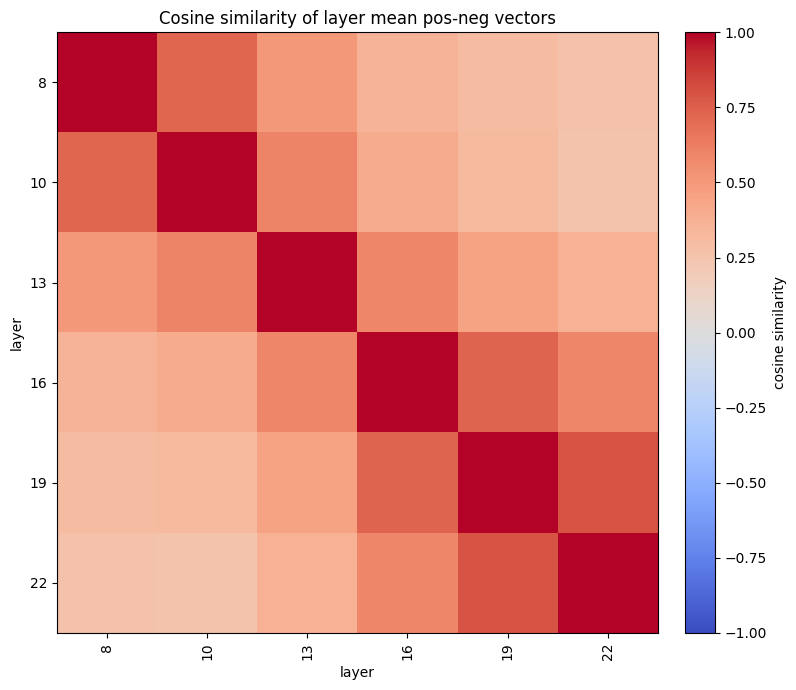

Saved layer vector cosine matrix to: /home/maplesugano/proj/EmotionEngine_v2/caa/results/layer_vector_cosine_matrix.csv


In [5]:
layer_vec_matrix = None

try:
    ordered_vectors = np.stack([mean_vectors[layer] for layer in layer_indices], axis=0)
    layer_vec_matrix = ordered_vectors @ ordered_vectors.T

    matrix_df = pd.DataFrame(layer_vec_matrix, index=layer_indices, columns=layer_indices)
    matrix_df.to_csv(RESULTS_DIR / "layer_vector_cosine_matrix.csv", index=True)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(layer_vec_matrix, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title("Cosine similarity of layer mean pos-neg vectors")
    ax.set_xlabel("layer")
    ax.set_ylabel("layer")
    ax.set_xticks(range(len(layer_indices)))
    ax.set_xticklabels(layer_indices, rotation=90)
    ax.set_yticks(range(len(layer_indices)))
    ax.set_yticklabels(layer_indices)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("cosine similarity")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "layer_vector_cosine_heatmap.png", dpi=200)
    display(fig)
    plt.close(fig)

    print(f"Saved layer vector cosine matrix to: {RESULTS_DIR / 'layer_vector_cosine_matrix.csv'}")
except Exception as exc:
    warnings.warn(f"Layer-to-layer cosine analysis failed: {exc}", RuntimeWarning)


## 5) Optional: relation among h_pos, h_neg, and h_base

For each layer, we compare:
- `cos(h_pos - h_base, h_pos - h_neg)`
- `cos(h_base - h_neg, h_pos - h_neg)`

This can be useful, but note that `h_base` can be difficult to interpret if it reflects only a prompt or incomplete rewrite context.

In [6]:
base_relation_rows = []

try:
    h_base_all = activations[:, 0, :, :]

    for layer_pos, layer_number in tqdm(
        list(enumerate(layer_indices)),
        desc="Base relation",
    ):
        h_base = h_base_all[:, layer_pos, :]
        h_pos = activations[:, 1, layer_pos, :]
        h_neg = activations[:, 2, layer_pos, :]

        d_pos_base = l2_normalize(h_pos - h_base)
        d_base_neg = l2_normalize(h_base - h_neg)
        d_pos_neg_layer = l2_normalize(h_pos - h_neg)

        cos_pos_base_vs_pos_neg = np.sum(d_pos_base * d_pos_neg_layer, axis=1)
        cos_base_neg_vs_pos_neg = np.sum(d_base_neg * d_pos_neg_layer, axis=1)

        base_relation_rows.append(
            {
                "layer": layer_number,
                "mean_cos_pos_minus_base_vs_pos_minus_neg": float(np.mean(cos_pos_base_vs_pos_neg)),
                "mean_cos_base_minus_neg_vs_pos_minus_neg": float(np.mean(cos_base_neg_vs_pos_neg)),
            }
        )

except Exception as exc:
    warnings.warn(f"Optional base relation analysis skipped: {exc}", RuntimeWarning)

base_relation_df = pd.DataFrame(base_relation_rows).sort_values("layer").reset_index(drop=True)
base_relation_df.to_csv(RESULTS_DIR / "base_relation_by_layer.csv", index=False)

display(base_relation_df.head())
print(f"Saved base relation table to: {RESULTS_DIR / 'base_relation_by_layer.csv'}")

Base relation: 100%|██████████| 6/6 [00:06<00:00,  1.03s/it]


,layer,mean_cos_pos_minus_base_vs_pos_minus_neg,mean_cos_base_minus_neg_vs_pos_minus_neg
0,8,0.260951,0.304573
1,10,0.224244,0.326801
2,13,0.274237,0.345246
3,16,0.288440,0.323160
4,19,0.312527,0.308364


Saved base relation table to: /home/maplesugano/proj/EmotionEngine_v2/caa/results/base_relation_by_layer.csv


## 6) Final interpretation guide

Strong evidence for a common positive-minus-negative direction is when:
- grouped logistic accuracy is high,
- ROC-AUC is high,
- `cos(d_i, mean_d)` is mostly positive,
- pairwise `d_i` cosine similarities are positive,
- and mean vectors are stable across adjacent layers.

Weak evidence is when:
- PCA looks separated but grouped classification is near chance,
- cosine similarities are centered near zero,
- pairwise `d_i` similarities are near zero.

Confound warning:
- If pairwise shifts are inconsistent or source/base clustering dominates, the pos-neg vector may include content, style, length, or rewrite artifacts rather than a clean emotion direction.

Expected outputs:
- `results/separability_layer_metrics.csv`
- `results/vector_consistency_by_layer.csv`
- `results/pairwise_consistency_by_layer.csv`
- `results/layer_vector_cosine_matrix.csv`
- `results/base_relation_by_layer.csv`
- `figures/pca_pos_neg_layer_{layer}.png`
- `figures/pca_pairs_layer_{layer}.png`
- `figures/cosine_hist_layer_{layer}.png`
- `figures/pairwise_cosine_hist_layer_{layer}.png`
- `figures/layer_vector_cosine_heatmap.png`